#


El objetivo de este trabajo es predecir el precio de venta de
propiedades en Capital Federal, aplicando el ciclo completo de un proyecto de
Machine Learning: desde la exploración de los datos hasta la evaluación de
distintos modelos.

## Carga de data, librerías y funciones

In [129]:
### Librerías
import pandas as pd
import numpy as np
import geopandas as gpd

import re
import unicodedata
import requests

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from matplotlib.ticker import ScalarFormatter, AutoLocator, FuncFormatter

import statsmodels.api as sm

from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, RidgeCV, LassoCV, ElasticNetCV
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_error
from matplotlib.gridspec import GridSpec
from sklearn.compose import ColumnTransformer
from sklearn import linear_model

In [2]:
# pequeña función para printear un objeto sin truncar
def print_full(x):
    pd.set_option('display.max_rows', len(x))
    print(x)
    pd.reset_option('display.max_rows')

In [3]:
### Data
# from google.colab import drive
# drive.mount('/content/drive')

## descarga del dataset
## https://drive.google.com/file/d/1o2P0Mg5mZgMZysrPHC8GKmwIg_QTzzN7/view

df = pd.read_csv('data/properati.csv')


## Exploración, Preprocesamiento y Trasnformación

In [4]:
print("Tipo de dato: " + str(type(df)))
print(str(df.shape[1]) + ' columnas')
print(str(df.shape[0]) + ' filas')

Tipo de dato: <class 'pandas.DataFrame'>
25 columnas
992192 filas


In [5]:
df.columns 

Index(['id', 'ad_type', 'start_date', 'end_date', 'created_on', 'lat', 'lon',
       'l1', 'l2', 'l3', 'l4', 'l5', 'l6', 'rooms', 'bedrooms', 'bathrooms',
       'surface_total', 'surface_covered', 'currency', 'price_period', 'title',
       'description', 'property_type', 'operation_type', 'price'],
      dtype='str')

In [118]:
dupl_df = df.duplicated()
any(dupl_df)


False

In [119]:
df.operation_type.value_counts()

operation_type
Venta                565263
Alquiler             171674
Alquiler temporal     20809
Name: count, dtype: int64

Vamos a dejar solo las propiedades en Venta. Las propiedades en Alquiler y Alquiler Temporal deberían entrenarse por separado.

In [120]:
# Dejamos solo los avisos de tipo 'Venta'
df = df.loc[df['operation_type'] == 'Venta'].copy()

Eliminamos la columna 'operation', ya que todos los valores son iguales

In [126]:
df.drop(columns=['operation_type'], inplace=True)
df.columns

Index(['id', 'ad_type', 'start_date', 'end_date', 'created_on', 'lat', 'lon',
       'country_name', 'state_name', 'county_name', 'city_name',
       'neighborhood_name', 'rooms', 'bedrooms', 'bathrooms', 'surface_total',
       'surface_covered', 'currency', 'price_period', 'title', 'description',
       'property_type', 'price', 'blue_venta', 'price_usd',
       'is_sospechoso_ars', 'price_usd_per_m2', 'housexstore'],
      dtype='str')

In [6]:
# exploramos el contenido de las columnas l1 a l6

for i in ["l1","l2","l3","l4","l5","l6"]:
    print(f"Value counts for column {i}:")
    print(df[i].value_counts())
    print()
    

Value counts for column l1:
l1
Argentina         973422
Uruguay            17929
Estados Unidos       783
Brasil                58
Name: count, dtype: int64

Value counts for column l2:
l2
Capital Federal                 249738
Buenos Aires Costa Atlántica    178712
Bs.As. G.B.A. Zona Norte        127510
Bs.As. G.B.A. Zona Sur          112975
Santa Fe                         93111
Bs.As. G.B.A. Zona Oeste         73172
Córdoba                          60877
Buenos Aires Interior            22280
Mendoza                          11558
Neuquén                          10642
Maldonado                        10101
Montevideo                        6318
Río Negro                         5507
Tucumán                           5425
Entre Ríos                        5113
Misiones                          4981
Salta                             3085
San Luis                          2101
Chaco                             1145
Corrientes                        1052
San Juan                       

Vemos que la columna "l1" = países; "l2" = regiones y/o provincias subnacionales; "l3" = departamentos y/o partidos; "l4" = localidades; "l5" = barrios. 

Vamos a renombrarlas con términos significativos (en inglés, ya que el resto de las columnas del dataset están en ese idioma):

In [7]:
df.rename(
    columns={
        "l1": "country_name",
        "l2": "state_name",
        "l3": "county_name",
        "l4": "city_name",
        "l5": "neighborhood_name",
    },
    inplace=True
)

Vamos a estandarizar las columnas textuales.

### Definimos data types

In [130]:
df.info()

<class 'pandas.DataFrame'>
Index: 565263 entries, 0 to 764912
Data columns (total 28 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   id                 565263 non-null  int64         
 1   ad_type            565263 non-null  str           
 2   start_date         565263 non-null  str           
 3   end_date           565263 non-null  datetime64[us]
 4   created_on         565263 non-null  datetime64[us]
 5   lat                472274 non-null  float64       
 6   lon                472425 non-null  float64       
 7   country_name       565263 non-null  str           
 8   state_name         565263 non-null  str           
 9   county_name        533306 non-null  str           
 10  city_name          114261 non-null  str           
 11  neighborhood_name  2661 non-null    str           
 12  rooms              226468 non-null  float64       
 13  bedrooms           187026 non-null  float64       
 14  bath

In [ ]:
# Columna de fechas
df['start_date'] = pd.to_datetime(df['start_date'])
df['end_date'] = pd.to_datetime(df['end_date'])
df['created_on'] = pd.to_datetime(df['created_on'])

In [132]:
def normalize_text(x):
    if pd.isna(x):
        return x
    x = str(x).strip().lower()
    # quita tildes/acentos
    x = unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("ascii")
    # deja letras, numeros, espacio, guion y underscore
    x = re.sub(r"[^\w\s-]", "", x)
    # espacios/guiones -> underscore
    x = re.sub(r"[\s-]+", "_", x)
    # colapsa underscores repetidos
    x = re.sub(r"_+", "_", x).strip("_")
    return x

# 1) nombres de columnas
df.columns = [normalize_text(c) for c in df.columns]

# 2) columnas string a normalizar (ajusta exclusiones segun tu caso)
string_cols = df.select_dtypes(include=["object", "string"]).columns
exclude_cols = {"title", "description"}  # opcional: texto libre
cols_to_normalize = [c for c in string_cols if c not in exclude_cols]

for c in cols_to_normalize:
    df[c] = df[c].map(normalize_text)

Para asegurarnos de no perder información relevante vamos a crear una columna para separar por tipo de propiedad.

Esto es porque es probable que existan registros duplicados en propiedades de tipo departamento, ya que es habitual que en un mismo edificio existan departamentos iguales y sean publicados por el mismo vendedor.

Por otro lado, en el caso de casas, es posible que dos casas sean iguales pero sería ilógico que tuvieran exactamente la misma localización geográfica, y podrían considerarse como registros duplicados.

In [122]:
# Creamos una columna para filtrar propiedades que sean casas o negocios
df['housexstore'] = df['property_type'].apply(lambda x: 'si' if x in ['house', 'store'] else 'no')

In [124]:

# Verificamos que tengamos duplicados las columnas que observamos previamente y la nueva columna
df[df['housexstore'] == 'si'].duplicated(subset=['title', 'description', 'lat-lon', 'housexstore']).value_counts()

df[df['housexstore'] == 'si'] = df[df['housexstore'] == 'si'].drop_duplicates(subset=['title', 'description', 'lat-lon', 'housexstore'], keep='first')

### Ingeniería de características

In [116]:
df.columns

Index(['id', 'ad_type', 'start_date', 'end_date', 'created_on', 'lat', 'lon',
       'country_name', 'state_name', 'county_name', 'city_name',
       'neighborhood_name', 'rooms', 'bedrooms', 'bathrooms', 'surface_total',
       'surface_covered', 'currency', 'price_period', 'title', 'description',
       'property_type', 'operation_type', 'price', 'blue_venta', 'price_usd',
       'is_sospechoso_ars', 'price_usd_per_m2'],
      dtype='str')

#### Datos faltantes o mal ingresados

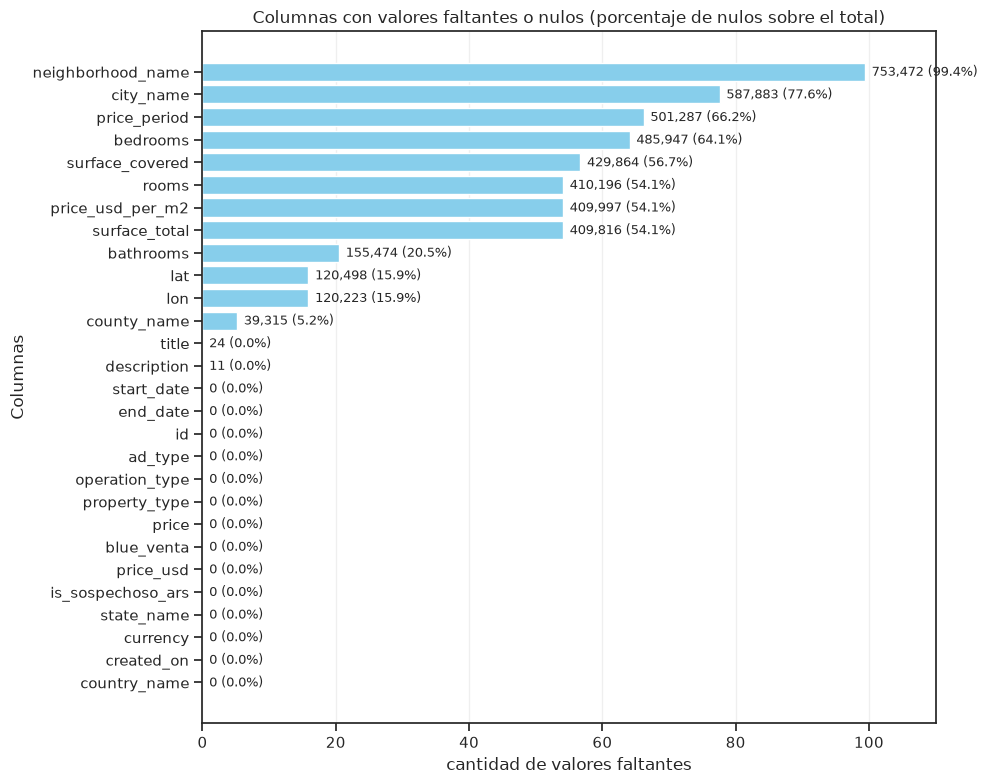

In [114]:
# evaluación de valores nulos en el dataset

columns_nanrows= df.isnull().sum()
columns_nanrows_percent = round(columns_nanrows/len(df)*100,1)
explore_nulls=pd.concat({'Rows sin data': columns_nanrows,'Porcentaje': columns_nanrows_percent},axis=1).sort_values(by='Rows sin data',ascending=False)
explore_nulls

explore_nulls_sorted = explore_nulls.sort_values(by='Rows sin data', ascending=True)
plt.figure(figsize=(10, 8))
plt.barh(explore_nulls_sorted.index, explore_nulls_sorted['Porcentaje'], color='skyblue')
plt.xlabel('cantidad de valores faltantes')
plt.ylabel('Columnas')
plt.title('Columnas con valores faltantes o nulos (porcentaje de nulos sobre el total)')
plt.xticks(rotation=0)
plt.grid(axis='x', alpha=0.3)
plt.xlim(0, 110)  # espacio para que entren las etiquetas

for i, col in enumerate(explore_nulls_sorted.index):
    faltantes = int(columns_nanrows[col])
    porcentaje = columns_nanrows_percent[col]
    x = explore_nulls_sorted.loc[col, 'Porcentaje']
    plt.text(x + 1, i, f'{faltantes:,} ({porcentaje:.1f}%)', va='center', fontsize=9)
plt.tight_layout()
plt.show()

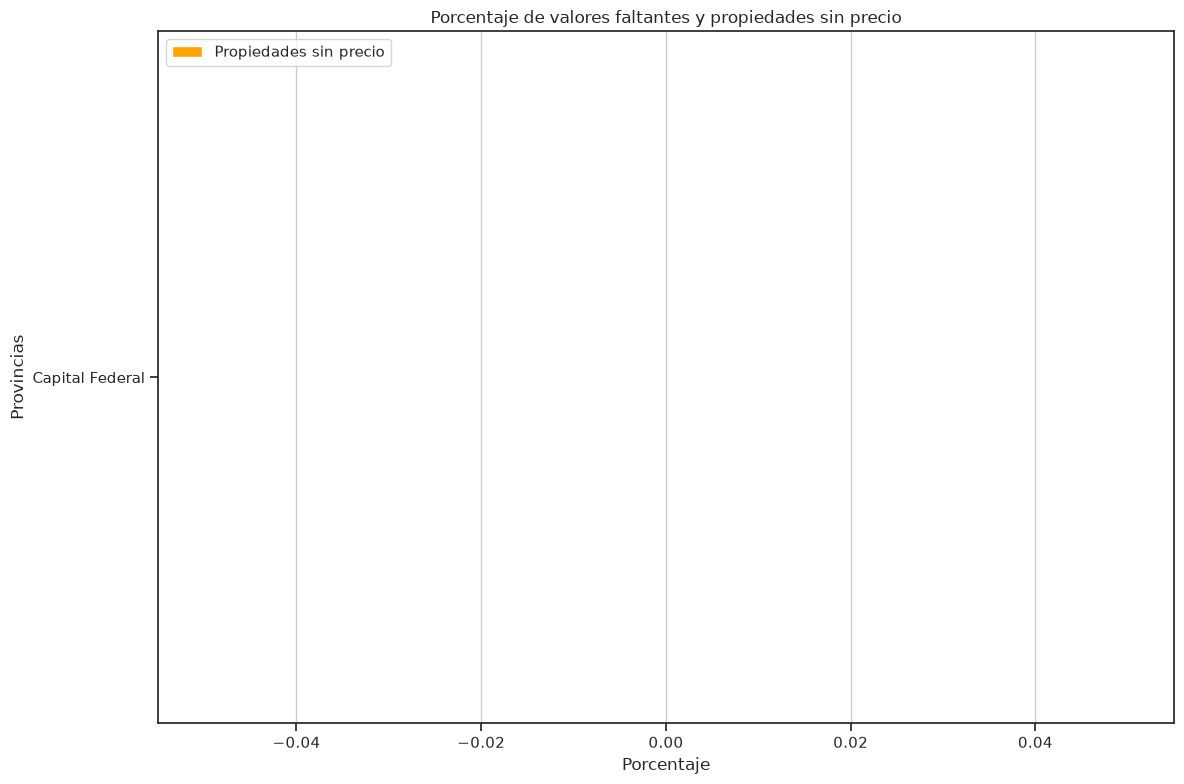

In [115]:
no_price_state_name = df[df["price"].isnull()][("state_name")].value_counts()
state_name = df["state_name"].value_counts()
state_name_percent = round(no_price_state_name/state_name*100,2)
table_state_name = pd.concat({"Propiedades Sin precio":no_price_state_name,"Propiedades Totales":state_name,"Porcentaje":state_name_percent},axis=1).sort_values(by="Porcentaje",ascending=False)
table_state_name

no_price_state_sorted = table_state_name.sort_values(by='Porcentaje', ascending=True)

plt.figure(figsize=(12, 8))
plt.barh(no_price_state_sorted.index, no_price_state_sorted['Porcentaje'], color='orange', label='Propiedades sin precio')
plt.xlabel('Porcentaje')
plt.ylabel('Provincias')
plt.title('Porcentaje de valores faltantes y propiedades sin precio')
plt.xticks(rotation=0)
plt.legend()
plt.grid(axis='x')
plt.tight_layout()
plt.show()

#### Columnas a descartar o crear

##### Descarte de variables

Vamos a descartar la volumna l6, por no contener información relevante. 

In [9]:
df.drop(columns=["l6"], inplace=True)

#### Outliers

In [ ]:

print("Rango de fechas de created_on: {} to {}".format(df.created_on.min(), df.created_on.max()))

Rango de fechas de created_on: 2019-07-04 00:00:00 to 2020-07-27 00:00:00


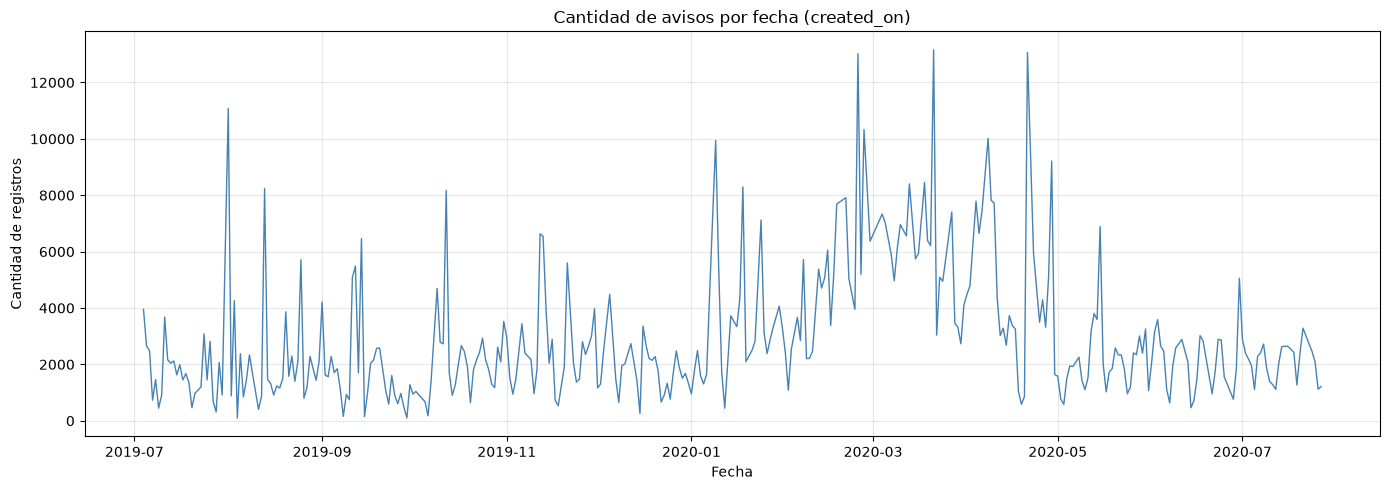

In [11]:
# Serie temporal: cantidad de avisos por fecha de creación (created_on)
created_on_dt = pd.to_datetime(df["created_on"], errors="coerce")
avisos_por_fecha = created_on_dt.value_counts().sort_index()

plt.figure(figsize=(14, 5))
plt.plot(avisos_por_fecha.index, avisos_por_fecha.values, color="steelblue", linewidth=1)
plt.title("Cantidad de avisos por fecha (created_on)")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de registros")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
print("Rango de fechas de end_date: {} to {}".format(df.end_date.min(), df.end_date.max()))

Rango de fechas de end_date: 2019-07-04 00:00:00 to 9999-12-31 00:00:00


"9999-12-31" como valor de fecha claramente es un registro inválido, vamos a evaluar cuántos avisos contienen fechas de cierre no válidos, buscando valores de cierre que estén fuera de un rango de fechas (min de created_on y una fecha actual).

In [18]:
# diagnóstico de la serie temporal de avisos cerrados por fecha (end_date)

# outliers de fecha
end_date_mask_out = (df.end_date < pd.Timestamp("2019-01-01")) | (df.end_date > pd.Timestamp("2026-09-30"))
print("Cantidad de registros con fechas fuera del rango:", end_date_mask_out.sum())

Cantidad de registros con fechas fuera del rango: 191147


In [19]:
# Vamos a eliminar los registros con fechas de cierre fuera del rango
df = df.loc[~end_date_mask_out] 

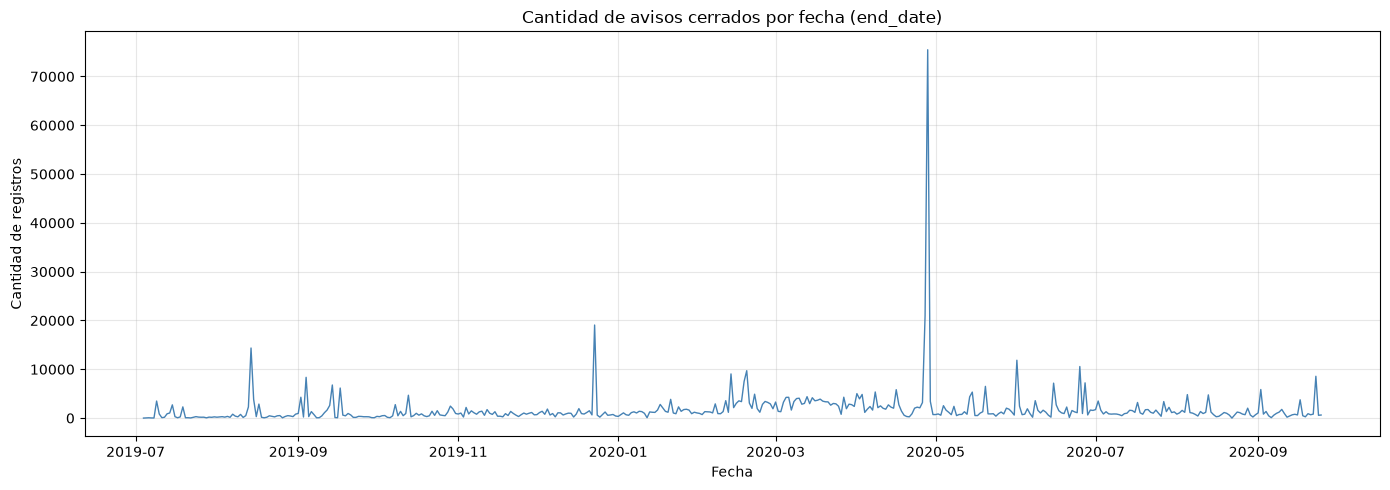

In [20]:
# Serie temporal: cantidad de avisos por fecha de cierre (end_date)
end_date_dt = pd.to_datetime(df["end_date"], errors="coerce")
avisos_por_fecha = end_date_dt.value_counts().sort_index()

plt.figure(figsize=(14, 5))
plt.plot(avisos_por_fecha.index, avisos_por_fecha.values, color="steelblue", linewidth=1)
plt.title("Cantidad de avisos cerrados por fecha (end_date)")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de registros")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Llevamos todos los precios a dólar estadounidense

In [133]:
# Vemos los valores únicos de la columna 'currency' y su frecuencia
df.currency.value_counts()

currency
usd    538831
ars     26432
Name: count, dtype: int64

Vamos a eliminar los registros de divisas que no son dólares ni pesos argentinos.

In [134]:
df = df[df.currency.isin(['usd', 'ars'])]

Descargamos la cotización del dolar blue histórico

In [23]:
# Descargamos la cotización del dolar blue histórico del sitio Argentina Datos
# ver más en https://argentinadatos.com/docs/operations/get-cotizaciones-dolares-casa.html

url_blue =    "https://api.argentinadatos.com/v1/cotizaciones/dolares/blue"
response_blue = requests.get(url_blue)
json_blue = response_blue.json()

# la request devuelve un JSON con la estructura:
# [  {    "moneda": "string",    "casa": "string",    "fecha": "string",    "compra": 0,    "venta": 0  }]

# convertimos el JSON a un DataFrame de pandas y parseamos la columna 'fecha' a tipo datetime
df_blue = pd.DataFrame(json_blue)
df_blue['fecha'] = pd.to_datetime(df_blue['fecha'])

# filtramos las filas de df_blue que están fuera del rango de fechas de df
blue_mask_out = (df_blue['fecha'] < df.created_on.min()) | (df_blue['fecha'] > df.created_on.max())
df_blue = df_blue.loc[~blue_mask_out]
df_blue = df_blue.sort_values('fecha')

print("Rango de fechas de df_blue: {} to {}".format(df_blue['fecha'].min(), df_blue['fecha'].max()))

Rango de fechas de df_blue: 2019-07-04 00:00:00 to 2020-07-27 00:00:00


In [24]:
# hacemos un merge de df para obtener la cotización del dólar blue más cercana hacia atrás

df = pd.merge_asof(
    df.sort_values('created_on'), df_blue[['venta','fecha']].sort_values('fecha'), left_on='created_on', right_on='fecha', direction='backward')

df.rename(columns={'venta': 'blue_venta'}, inplace=True)


In [25]:
# mostramos las columnas relevantes para verificar el merge
df[['created_on', 'blue_venta','fecha']].sample(20)

,created_on,blue_venta,fecha
170208,2019-10-26,76,2019-10-26
236965,2019-12-05,69,2019-12-05
629862,2020-04-24,118,2020-04-24
451111,2020-03-08,78,2020-03-08
180770,2019-11-01,68,2019-11-01
517622,2020-03-21,86,2020-03-21
15668,2019-07-13,43,2019-07-13
115700,2019-09-14,62,2019-09-14
95970,2019-09-04,60,2019-09-04
517780,2020-03-21,86,2020-03-21


In [ ]:
# Eliminamos la columna 'fecha' xq ya no es necesaria
df.drop(columns=['fecha'], inplace=True)

Antes de convertir los valores en pesos a dólares evaluamos la distribución de precios en pesos y en dólares con el objetivo de entender mejor la distribución y detectar posibles outliers o errores.

Para eso vamos a definir una heurística para detectar registros con precios en pesos inconsistentes. Vamos a tomar los avisos en ARS y calcular su precio implícito en USD dividiendo "price" por "blue_venta",  

Luego usando como referencia la distribución de los avisos que ya están correctamente publicados en USD, vamos a marcar como registros en pesos sospechosos aquellos avisos en ARS cuyo precio en USD una vez convertidos quedan por debajo del percentil 3 de los precios en USD. Como validación adicional, observamos si esos casos se concentran en montos redondos, lo que refuerza la hipótesis de una moneda mal definida.

Cantidad de sospechosos: 3358


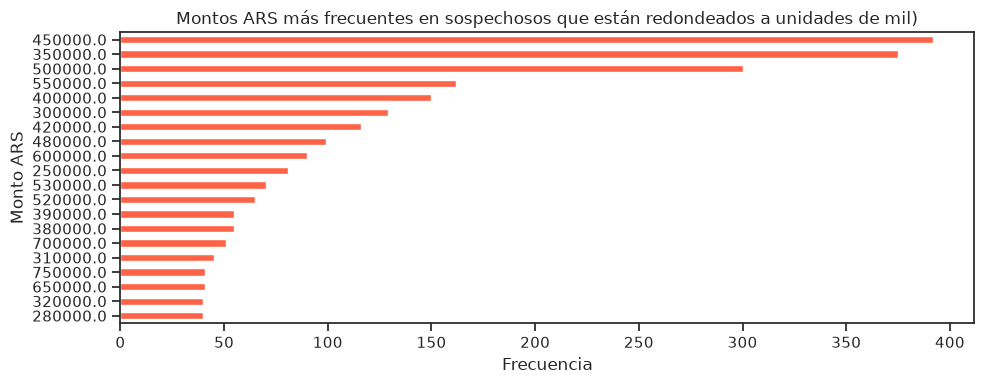

,created_on,price,blue_venta,price_usd_impl,property_type,state_name
338039,2020-01-31,1.0,78,0.012821,otro,cordoba
446252,2020-03-07,1.0,78,0.012821,otro,tucuman
329840,2020-01-27,111.0,78,1.423077,departamento,buenos_aires_interior
714513,2020-06-09,120.0,124,0.967742,departamento,santa_fe
571949,2020-04-05,950.0,84,11.309524,otro,misiones
642668,2020-04-28,1111.0,119,9.336134,otro,tucuman
130147,2019-09-30,1276.0,61,20.918033,otro,mendoza
274745,2020-01-06,10000.0,77,129.870130,otro,cordoba
272378,2020-01-04,10000.0,77,129.870130,otro,cordoba
274667,2020-01-06,13000.0,77,168.831169,otro,cordoba


In [135]:
# Separamos el dataset  de los datos por moneda 
ars = df[df["currency"].eq("ars")].copy()
usd = df[df["currency"].eq("usd")].copy()

# Precio implícito en USD para avisos ARS
ars["price_usd_impl"] = ars["price"] / ars["blue_venta"]

# thresholds (umbrales)
## Umbral de sospecha - muy por debajo de lo típico en USD
usd_p03 = usd_vals.quantile(0.03)
## Percentiles "creíbles" - rango típico de precios en USD
p10_usd, p90_usd = usd_vals.quantile([0.10, 0.90])


# Registros sospechosos de posible moneda mal definida
sospechosos = ars[(ars["price_usd_impl"] < usd_p03)     # implícitamente muy baratos en USD
].copy()

print("Cantidad de sospechosos:", len(sospechosos))



# ¿Se concentran en números redondos?
plt.figure(figsize=(10, 4))
sospechosos["price"].round(-3).value_counts().head(20).sort_values().plot(kind="barh", color="tomato")
plt.title("Montos ARS más frecuentes en sospechosos que están redondeados a unidades de mil)")
plt.xlabel("Frecuencia")
plt.ylabel("Monto ARS")
plt.tight_layout()
plt.show()


display(
    sospechosos[["created_on", "price", "blue_venta", "price_usd_impl", "property_type", "state_name"]]
    .sort_values("price")
    .head(30)
)

% ARS implícito por debajo de P03 USD: 12.70%
% ARS implícito dentro del rango P10-P90 de USD real: 34.66%


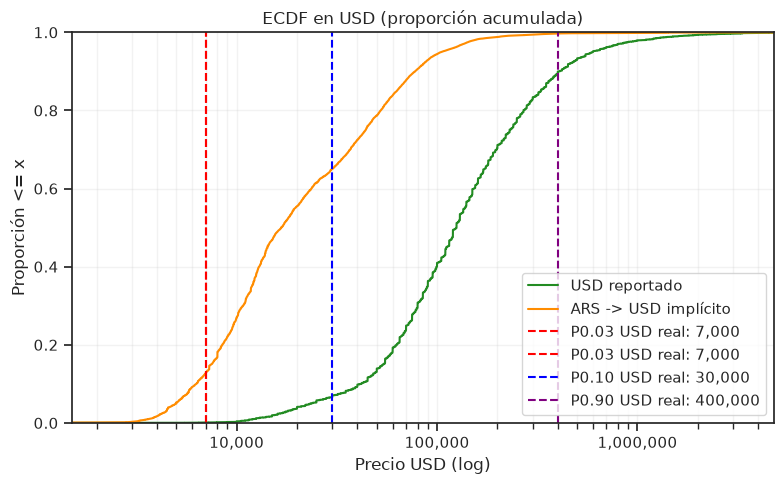

In [136]:
# Proporciones de ARS implícito bajo ciertos umbrales de USD real
share_below_p03 = (ars["price_usd_impl"] < usd_p03).mean()
print(f"% ARS implícito por debajo de P03 USD: {share_below_p03:.2%}")

share_in_core_usd = ((ars["price_usd_impl"] >= p10_usd) & (ars["price_usd_impl"] <= p90_usd)).mean()
print(f"% ARS implícito dentro del rango P10-P90 de USD real: {share_in_core_usd:.2%}")


# Curva acumulada para leer proporciones de avisos en pesos que convertidos 
# quedan bajo umbral de usd_p03

# Formateador simple
fmt = FuncFormatter(lambda x, _: f"{x:,.0f}")

# Rangos robustos para comparar visualmente
lo = min(usd["price"].quantile(0.001), ars["price_usd_impl"].quantile(0.001))
hi = max(usd["price"].quantile(0.999), ars["price_usd_impl"].quantile(0.999))

def ecdf(x):
    x = np.sort(x)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

xu, yu = ecdf(usd["price"])
xa, ya = ecdf(ars["price_usd_impl"])

plt.figure(figsize=(8, 5))
plt.plot(xu, yu, label="USD reportado", color="forestgreen")
plt.plot(xa, ya, label="ARS -> USD implícito", color="darkorange")
plt.axvline(usd_p03, color="red", linestyle="--", label=f"P0.03 USD real: {usd_p03:,.0f}")
plt.axvline(usd_p03, color="red", linestyle="--", label=f"P0.03 USD real: {usd_p03:,.0f}")
plt.axvline(p10_usd, color="blue", linestyle="--", label=f"P0.10 USD real: {p10_usd:,.0f}")
plt.axvline(p90_usd, color="purple", linestyle="--", label=f"P0.90 USD real: {p90_usd:,.0f}")
plt.xscale("log")
plt.xlim(lo, hi)
plt.ylim(0, 1)
plt.title("ECDF en USD (proporción acumulada)")
plt.xlabel("Precio USD (log)")
plt.ylabel("Proporción <= x")
plt.gca().xaxis.set_major_formatter(fmt)
plt.grid(alpha=0.25, which="both")
plt.legend()
plt.tight_layout()
plt.show()

Esos resultados son una señal muy fuerte de mala catalogación en ARS. 8 de cada 10 avisos en ARS, convertidos a USD's, quedan en una zona extremadamente baja para precios de venta. Sólo el 4.59% de los avisos en ARS una vez convertidos se comportan como precios de propiedades bien etiquetados.

Vamos a crear una columna de avisos en ARS "sospechosos". Estos registros van a definir su precio en dólares sin la conversión cambiaria. 

In [87]:
### Dummy de registros sospechosos (ARS mal catalogados)
df["is_sospechoso_ars"] = df.index.isin(sospechosos.index).astype(int)


In [137]:
# Unifica precio en USD sin perder columnas originales
df["price_usd"] = np.where(
    df["currency"].eq("usd") | (df["currency"].eq("ars") & df["is_sospechoso_ars"].eq(1)),
    df["price"],
    np.where(df["currency"].eq("ars"), df["price"] / df["blue_venta"], np.nan)
)

# vista rápida de control
df[["currency", "is_sospechoso_ars", "price", "price_usd"]].sample(50)

,currency,is_sospechoso_ars,price,price_usd
702568,usd,0,159000.0,1.590000e+05
409059,ars,0,1500000.0,1.898734e+04
124823,usd,0,18000.0,1.800000e+04
510117,usd,0,11000.0,1.100000e+04
279920,usd,0,118000.0,1.180000e+05
325940,usd,0,100000.0,1.000000e+05
742803,usd,0,200000.0,2.000000e+05
131966,usd,0,255000.0,2.550000e+05
374209,usd,0,280000.0,2.800000e+05
390099,usd,0,129000.0,1.290000e+05


##### Creación de la columna price_per_m2

In [90]:
df.columns

Index(['id', 'ad_type', 'start_date', 'end_date', 'created_on', 'lat', 'lon',
       'country_name', 'state_name', 'county_name', 'city_name',
       'neighborhood_name', 'rooms', 'bedrooms', 'bathrooms', 'surface_total',
       'surface_covered', 'currency', 'price_period', 'title', 'description',
       'property_type', 'operation_type', 'price', 'blue_venta', 'price_usd',
       'is_sospechoso_ars'],
      dtype='str')

In [108]:
##### Creación de la columna price_per_m2

df["price_usd_per_m2"] = df["price_usd"] / df["surface_total"].replace(0, np.nan)


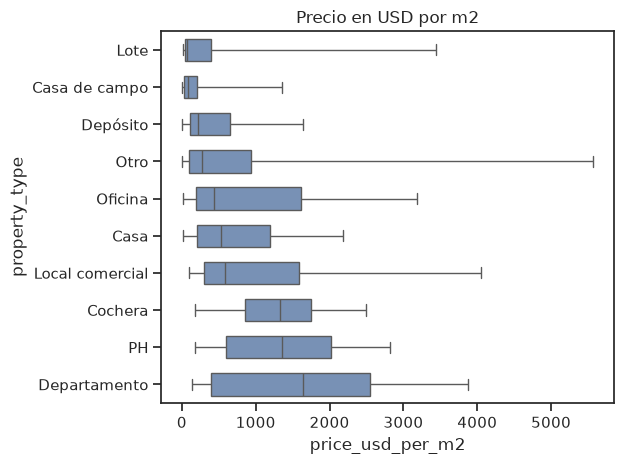

In [110]:
sns.set_theme(style="ticks", palette="vlag")

plot_df = df.loc[np.isfinite(df["price_usd_per_m2"]) & (df["price_usd_per_m2"] > 0), 
                 ["price_usd_per_m2", "property_type"]]

order = (
    plot_df.groupby("property_type")["price_usd_per_m2"]
    .median()
    .sort_values()
    .index
)

sns.boxplot(
    data=plot_df,
    x="price_usd_per_m2",
    y="property_type",
    order=order,
    whis=(5, 95),
    showfliers=False,
    width=0.6
)
plt.title('Precio en USD por m2')
ax.set_xscale("log")

plt.tight_layout()
plt.show()

#### Encoding

### Visualización de los datos

una primera aproximación al dataset apoyándote en visualizaciones, por
ejemplo: distribución de precios, comparación de precios por tipo de propiedad,
relación entre superficie y precio, mapas o gráficos geográficos, matrices de
correlación, o cualquier otro gráfico que consideres útil. Justificá por qué
elegiste cada uno y qué te permitió descubrir.

Procedemos a visualizar la distribución según la columna state_name de la cantidad de publicaciónes.

Vamos a utilizar un grafico de torta y vamos a categorizar como "otros" aquellas que representen menos del 7% en post de la claridad del grafico

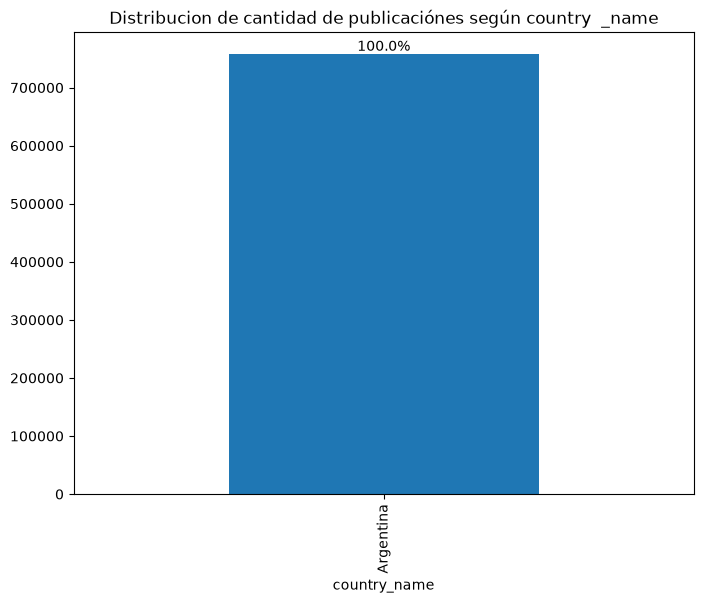

In [95]:
country_counts =  df['country_name'].value_counts()
# threshold de pequeñas categorias
threshold = 0.07 * len(df)
Categorias_chicas = country_counts[country_counts < threshold].index
s_country_name = df['country_name'].apply(lambda x: 'Otros' if x in Categorias_chicas else x)
plt.figure(figsize=(8, 6))
country_vc = s_country_name.value_counts()
ax = country_vc.plot(kind='bar')

total = country_vc.sum()
for p in ax.patches:
    pct = 100 * p.get_height() / total
    ax.annotate(f'{pct:.1f}%', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')
plt.title('Distribucion de cantidad de publicaciónes según country  _name')
plt.ylabel('')
plt.show()

Vamos a dejar solo los registros de Argentina

In [94]:
df = df[df["country_name"].eq("Argentina")].copy()


Veamos la distribución a nivel Región / Provincia

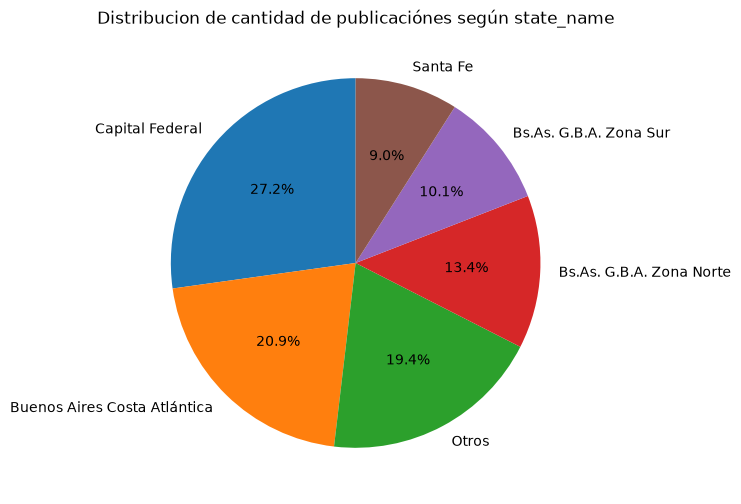

In [96]:
state_counts =  df['state_name'].value_counts()
# threshold de pequeñas categorias
threshold = 0.07 * len(df)
Categorias_chicas = state_counts[state_counts < threshold].index
s_state_name = df['state_name'].apply(lambda x: 'Otros' if x in Categorias_chicas else x)
plt.figure(figsize=(8, 6))
s_state_name.value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Distribucion de cantidad de publicaciónes según state_name')
plt.ylabel('')
plt.show()

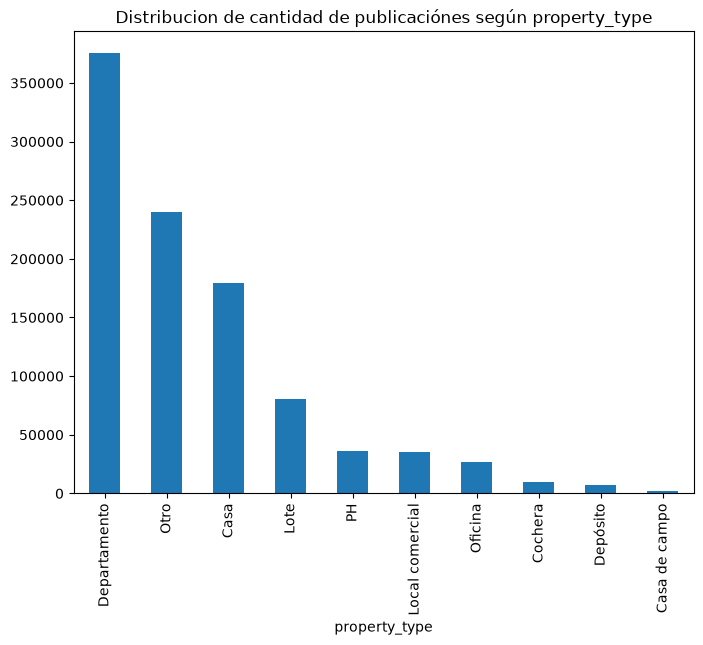

In [90]:
plt.figure(figsize=(8, 6))
df['property_type'].value_counts().plot(kind='bar')
plt.title('Distribucion de cantidad de publicaciónes según property_type')
plt.ylabel('')
plt.show()

### Descripción de los dataset

Resumí qué pudiste descubrir sobre el dataset a partir de los puntos anteriores.
Definí también, en esta sección, qué métrica(s) vas a usar para evaluar el
desempeño de los modelos (por ejemplo, MAE) y justificá por qué son
adecuadas para este problema de regresión en particular.

## Parte 2: Generación y Evaluación de Modelos

### Modelos

Dividí el conjunto de datos en entrenamiento/prueba y posteriormente entrená
al menos un modelo de Regresión Lineal y otro de Random Forest. Para este
último documentá y justificá los hiperparámetros elegidos

### Búsqueda de hiperparámetros

Utilizá GridSearchCV (u otra técnica de búsqueda de hiperparámetros) sobre
Random Forest. Compará el rendimiento del mejor modelo encontrado contra
la versión sin ajustar.

### Conclusiones

Resumí qué modelo recomendarías para este problema y por qué.
